In [1]:
import os
print("CWD:", os.getcwd())

import sys
print("PATH:", sys.path)

CWD: /Users/saif/Projects/DAI/multi-agent-frost-prediction-system/notebooks
PATH: ['/Users/saif/Projects/DAI/multi-agent-frost-prediction-system/notebooks', '/Library/Frameworks/Python.framework/Versions/3.12/lib/python312.zip', '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12', '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/lib-dynload', '', '/Users/saif/Projects/DAI/multi-agent-frost-prediction-system/venv/lib/python3.12/site-packages']


In [2]:
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.data_loader import load_graz_frost_dataset
plt.style.use("seaborn-v0_8")

In [5]:
df = load_graz_frost_dataset("../data/raw/graz_tmin.txt")

df#.head()
df.columns

Index(['DATE', 'TN_C', 'target_frost'], dtype='str')

In [6]:
#Data Info
print("Shape:", df.shape)
print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Frost days:", df["target_frost"].sum())
print("Non-frost days:", len(df) - df["target_frost"].sum())

Shape: (11987, 3)
Date range: 1990-01-01 00:00:00 to 2023-06-27 00:00:00
Frost days: 2831.0
Non-frost days: 9156.0


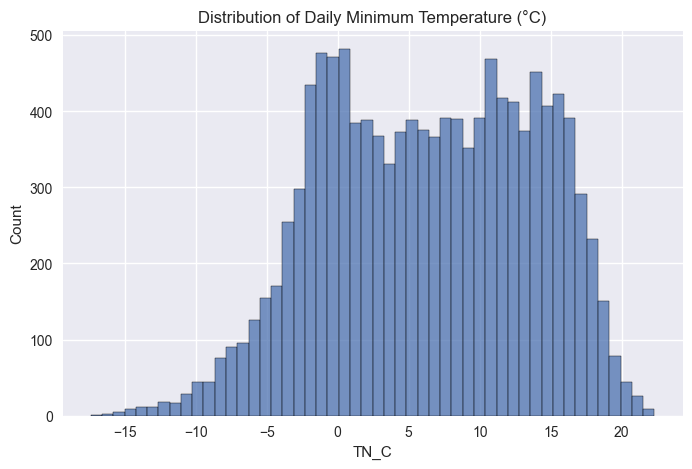

In [7]:
#Temperature Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["TN_C"], bins=50)
plt.title("Distribution of Daily Minimum Temperature (°C)")
plt.show()

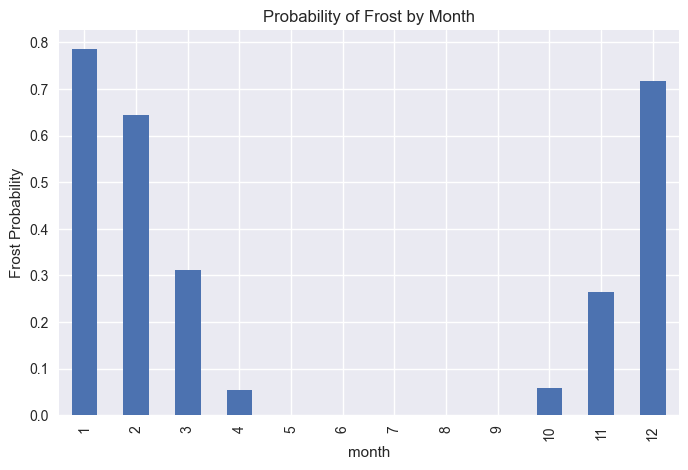

In [8]:
#Frost Frequency by Month
df["month"] = df["DATE"].dt.month

monthly_frost = df.groupby("month")["target_frost"].mean()

plt.figure(figsize=(8,5))
monthly_frost.plot(kind="bar")
plt.title("Probability of Frost by Month")
plt.ylabel("Frost Probability")
plt.show()

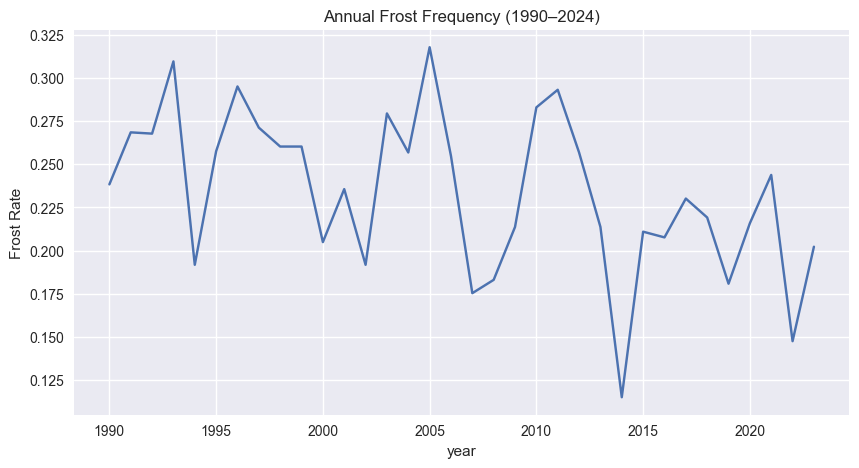

In [9]:
#Frost Trend Over Years
df["year"] = df["DATE"].dt.year

annual_frost = df.groupby("year")["target_frost"].mean()

plt.figure(figsize=(10,5))
annual_frost.plot()
plt.title("Annual Frost Frequency (1990–2024)")
plt.ylabel("Frost Rate")
plt.show()